In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.0/879.0 kB 10.6 MB/s eta 0:00:00


In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



image 1/1 /content/drive/MyDrive/cross/p1065600372208737_475_thum.jpg: 640x512 1 red, 19.9ms
Speed: 3.8ms preprocess, 19.9ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 512)


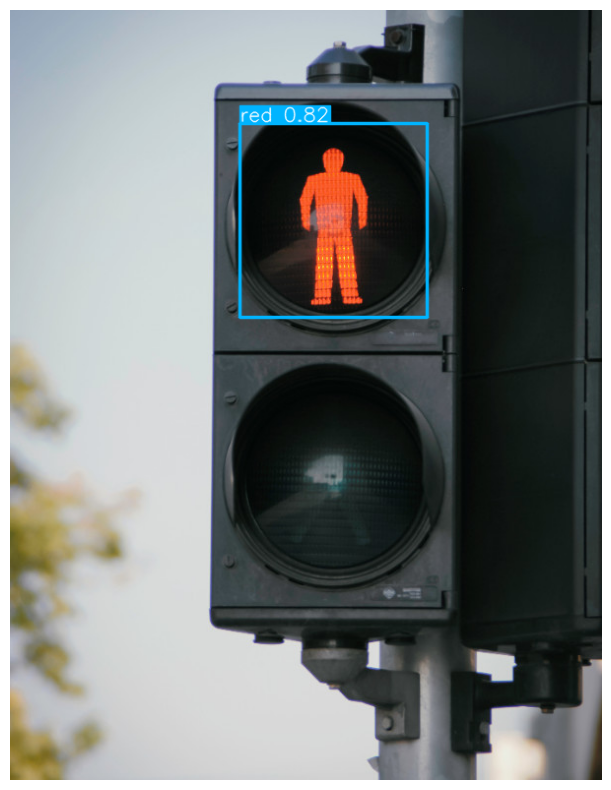

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. 모델 불러오기
model = YOLO("/content/drive/MyDrive/cross/best_model2.pt")  # 학습한 모델의 경로를 설정하세요.

# 2. 이미지 경로 지정
test_images = ["/content/drive/MyDrive/cross/p1065600372208737_475_thum.jpg"]  # 테스트할 이미지 경로

# 3. 검출 수행 및 결과 표시
for img_path in test_images:
    results = model(img_path)  # 이미지에 대해 예측 수행
    for result in results:
        # 결과 이미지 불러오기
        img = result.plot()  # 결과 이미지 가져오기
        # matplotlib으로 결과 표시
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

# **2. 새로운 데이터로 전이학습 하기 **


# **kick board, red, green, crosswalk shuffle 후 8:2 **



In [ ]:
import os
import random
import shutil

In [ ]:
def shuffle_and_split_dataset(src_dir, dst_dir, train_ratio=0.8):
    # src_dir에 있는 모든 jpg 및 png 파일과 해당하는 txt 파일 가져오기
    all_files = []

    for filename in os.listdir(src_dir):
        if filename.lower().endswith(('.jpg', '.png')):
            base_filename = filename.rsplit('.', 1)[0]
            img_file = os.path.join(src_dir, filename)
            txt_file = os.path.join(src_dir, f"{base_filename}.txt")
            if os.path.exists(txt_file):
                all_files.append((img_file, txt_file))

    # 파일 개수 확인
    total_files = len(all_files)
    print(f"총 파일 개수: {total_files}")

    # 파일 섞기
    random.shuffle(all_files)

    # Train/Val 폴더 생성
    train_dir = os.path.join(dst_dir, 'train_new')
    val_dir = os.path.join(dst_dir, 'val_new')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    # Train/Val split
    train_size = int(total_files * train_ratio)
    train_files = all_files[:train_size]
    val_files = all_files[train_size:]

    # Train 데이터 복사
    for img_file, txt_file in train_files:
        shutil.copyfile(img_file, os.path.join(train_dir, os.path.basename(img_file)))
        shutil.copyfile(txt_file, os.path.join(train_dir, os.path.basename(txt_file)))

    # Val 데이터 복사
    for img_file, txt_file in val_files:
        shutil.copyfile(img_file, os.path.join(val_dir, os.path.basename(img_file)))
        shutil.copyfile(txt_file, os.path.join(val_dir, os.path.basename(txt_file)))

    # 결과 확인
    print(f"Train 파일 수: {len(train_files)}")
    print(f"Val 파일 수: {len(val_files)}")

# 사용 예제
src_dir = '/content/drive/MyDrive/cross/new_label/label_combined'  # 원본 데이터 폴더 경로
dst_dir = '/content/drive/MyDrive/cross/split'  # 나눌 데이터 폴더 경로

shuffle_and_split_dataset(src_dir, dst_dir, train_ratio=0.8)

총 파일 개수: 429
Train 파일 수: 343
Val 파일 수: 86


In [ ]:
!unzip

In [ ]:
def shuffle_and_split_dataset(src_dir, dst_dir, train_ratio=0.8):
    # src_dir에 있는 모든 jpg 및 png 파일과 해당하는 txt 파일 가져오기
    all_files = []

    for filename in os.listdir(src_dir):
        if filename.lower().endswith(('.jpg', '.png')):
            base_filename = filename.rsplit('.', 1)[0]
            img_file = os.path.join(src_dir, filename)
            txt_file = os.path.join(src_dir, f"{base_filename}.txt")
            if os.path.exists(txt_file):
                all_files.append((img_file, txt_file))

    # 파일 개수 확인
    total_files = len(all_files)
    print(f"총 파일 개수: {total_files}")

    # 파일 섞기
    random.shuffle(all_files)

    # Train/Val 폴더 생성
    train_dir = os.path.join(dst_dir, 'train_new')
    val_dir = os.path.join(dst_dir, 'val_new')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    # Train/Val split
    train_size = int(total_files * train_ratio)
    train_files = all_files[:train_size]
    val_files = all_files[train_size:]

    # Train 데이터 복사
    for img_file, txt_file in train_files:
        shutil.copyfile(img_file, os.path.join(train_dir, os.path.basename(img_file)))
        shutil.copyfile(txt_file, os.path.join(train_dir, os.path.basename(txt_file)))

    # Val 데이터 복사
    for img_file, txt_file in val_files:
        shutil.copyfile(img_file, os.path.join(val_dir, os.path.basename(img_file)))
        shutil.copyfile(txt_file, os.path.join(val_dir, os.path.basename(txt_file)))

    # 결과 확인
    print(f"Train 파일 수: {len(train_files)}")
    print(f"Val 파일 수: {len(val_files)}")

# 사용 예제
src_dir = '/content/drive/MyDrive/cross/new_label/label_combined'  # 원본 데이터 폴더 경로
dst_dir = '/content/drive/MyDrive/cross/split'  # 나눌 데이터 폴더 경로

shuffle_and_split_dataset(src_dir, dst_dir, train_ratio=0.8)

In [ ]:
len(os.listdir('/content/drive/MyDrive/cross/split/train_new')) # 686

686

In [ ]:
len(os.listdir('/content/drive/MyDrive/cross/split/val_new'))  # 172

172

# **traffic_light 제거 **

In [ ]:
# id 6 (traffic light) 제거
import os

def remove_traffic_light_labels(input_folder):
    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            with open(os.path.join(input_folder, filename), 'r') as file:
                lines = file.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])
                if class_id != 6:  # traffic_light class id
                    new_lines.append(line.strip())

            with open(os.path.join(input_folder, filename), 'w') as file:
                file.write("\n".join(new_lines))

# 사용 예시
input_folder = '/content/drive/MyDrive/cross/split/train'  # 기존 train 폴더
remove_traffic_light_labels(input_folder)


In [ ]:
# id 6 (traffic light) val 폴더에서도 제거
import os

def remove_traffic_light_labels(input_folder):
    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            with open(os.path.join(input_folder, filename), 'r') as file:
                lines = file.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])
                if class_id != 6:  # traffic_light class id
                    new_lines.append(line.strip())

            with open(os.path.join(input_folder, filename), 'w') as file:
                file.write("\n".join(new_lines))

# 사용 예시
input_folder = '/content/drive/MyDrive/cross/split/val'  # 기존 val 폴더
remove_traffic_light_labels(input_folder)

In [ ]:
import os

def adjust_class_ids(input_folder):
    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            with open(os.path.join(input_folder, filename), 'r') as file:
                lines = file.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])

                # 모든 클래스 ID를 6 이하의 경우를 제외하고 1씩 줄임
                if class_id > 6:  # traffic_light 이전 ID는 그대로 유지
                    class_id -= 1

                new_lines.append(f"{class_id} " + " ".join(parts[1:]))

            # 새 라벨 파일로 덮어쓰기
            with open(os.path.join(input_folder, filename), 'w') as file:
                file.write("\n".join(new_lines))

# 사용 예시
train_folder = '/content/drive/MyDrive/cross/split/train'
train_new_folder = '/content/drive/MyDrive/cross/split/train_new'
val_folder = '/content/drive/MyDrive/cross/split/val'
val_new_folder = '/content/drive/MyDrive/cross/split/val_new'

# 각 폴더에서 클래스 ID 조정
adjust_class_ids(train_folder)
adjust_class_ids(train_new_folder)
adjust_class_ids(val_folder)
adjust_class_ids(val_new_folder)

print("모든 폴더에서 클래스 ID 조정이 완료되었습니다.")



모든 폴더에서 클래스 ID 조정이 완료되었습니다.


In [ ]:
import os

def restore_class_ids(input_folder):
    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            with open(os.path.join(input_folder, filename), 'r') as file:
                lines = file.readlines()

            restored_lines = []
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])

                # 모든 클래스 ID를 6 이하의 경우를 제외하고 1씩 늘림
                if class_id >= 6:
                    class_id += 1

                restored_lines.append(f"{class_id} " + " ".join(parts[1:]))

            # 새 라벨 파일로 덮어쓰기
            with open(os.path.join(input_folder, filename), 'w') as file:
                file.write("\n".join(restored_lines))

# 사용 예시
train_folder = '/content/drive/MyDrive/cross/split/train'
train_new_folder = '/content/drive/MyDrive/cross/split/train_new'
val_folder = '/content/drive/MyDrive/cross/split/val'
val_new_folder = '/content/drive/MyDrive/cross/split/val_new'

# 각 폴더에서 클래스 ID 복원
restore_class_ids(train_folder)
restore_class_ids(train_new_folder)
restore_class_ids(val_folder)
restore_class_ids(val_new_folder)

print("모든 폴더에서 클래스 ID 복원이 완료되었습니다.")


모든 폴더에서 클래스 ID 복원이 완료되었습니다.


In [ ]:
import yaml
from ultralytics import YOLO

# 데이터셋 경로 및 클래스 정보 설정
data_yaml = {
    'train': [
        '/content/drive/MyDrive/cross/split/train',
        '/content/drive/MyDrive/cross/split/train_new'
    ],
    'val': [
        '/content/drive/MyDrive/cross/split/val',
        '/content/drive/MyDrive/cross/split/val_new'
    ],
    'nc': 32,  # 총 클래스 수 (0-28: 기존 클래스, 29-31: 새로운 클래스)
    'names': [
        'traffic_light_controller', 'power_controller', 'wheelchair', 'truck',
        'tree_trunk', 'traffic_sign', 'table', 'stroller', 'stop', 'scooter',
        'potted_plant', 'pole', 'person', 'parking_meter', 'movable_signage',
        'motorcycle', 'kiosk', 'fire_hydrant', 'dog', 'chair', 'cat',
        'carrier', 'car', 'bus', 'bollard', 'bicycle', 'bench', 'barricade',
        'kickboard', 'red', 'green', 'crosswalk'
    ]  # 'traffic_light'를 제거한 상태
}

# yaml 파일 저장 경로 설정
yaml_file_path = '/content/drive/MyDrive/cross/no_traffic.yaml'

# data.yaml 파일 생성
with open(yaml_file_path, 'w') as yaml_file:
    yaml.dump(data_yaml, yaml_file, default_flow_style=False)

print(f"data.yaml 파일이 {yaml_file_path} 경로에 성공적으로 생성되었습니다.")


data.yaml 파일이 /content/drive/MyDrive/cross/no_traffic.yaml 경로에 성공적으로 생성되었습니다.


In [ ]:
# 클래스 번호 변경으로 전이학습이 아닌 새로운 모델 생성

from ultralytics import YOLO

# 새 모델 학습
model = YOLO('yolov8n')  # YOLOv8s 모델을 새로 생성
model.train(data='/content/drive/MyDrive/cross/no_traffic.yaml', epochs=50, imgsz=640)

# 모델 저장
model.save('/content/drive/MyDrive/cross/nt.pt')

Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/cross/no_traffic.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_co

train: Scanning /content/drive/MyDrive/cross/split/train... 823 images, 1 backgrounds, 0 corrupt: 100%|██████████| 823/823 [00:07<00:00, 112.82it/s]


train: New cache created: /content/drive/MyDrive/cross/split/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/drive/MyDrive/cross/split/val.cache... 206 images, 0 backgrounds, 0 corrupt: 100%|██████████| 206/206 [00:00<?, ?it/s]


Plotting labels to runs/detect/train5/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000278, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train5
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      2.36G       1.09      1.134      1.037         45        640: 100%|██████████| 52/52 [00:27<00:00,  1.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.15it/s]

                   all        206       1252      0.607      0.475      0.506      0.332



50 epochs completed in 0.513 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 6.2MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,011,888 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:07<00:00,  1.08s/it]


                   all        206       1252      0.568      0.486      0.511      0.334
traffic_light_controller         10         10      0.364        0.3      0.338      0.272
      power_controller          3          5      0.306        0.6      0.319      0.224
                 truck         42         57      0.387      0.544      0.489      0.314
            tree_trunk         97        227      0.621      0.863       0.83      0.476
          traffic_sign         46         94       0.57      0.457      0.496      0.294
                 table          1          1          0          0          0          0
                  stop          7          7      0.611      0.571      0.664      0.483
          potted_plant          5          8          1          0      0.167     0.0606
                  pole         71        118      0.634      0.771      0.736      0.434
                person         45         94       0.59      0.617      0.631      0.351
       movable_sign

In [ ]:
import os

def check_labels(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            with open(os.path.join(folder_path, filename), 'r') as f:
                lines = f.readlines()
                for line in lines:
                    # 라벨의 첫 번째 요소가 클래스 ID임
                    class_id = int(line.split()[0])
                    if class_id >= 32:  # 32 이상의 ID가 있는지 확인
                        print(f"Error: {filename} contains class ID {class_id}")

# 라벨 파일이 있는 폴더 경로 설정
train_folder = '/content/drive/MyDrive/cross/split/train'
train_new_folder = '/content/drive/MyDrive/cross/split/train_new'

# 라벨 체크
check_labels(train_folder)
check_labels(train_new_folder)


# **기존 코드 **

In [ ]:
# 기존 코드 !!!!!

import yaml
from ultralytics import YOLO

# 데이터셋 경로 및 클래스 정보 설정
data_yaml = {
    'train': [
        '/content/drive/MyDrive/cross/split/train',  # 기존 학습 데이터 경로
        '/content/drive/MyDrive/cross/split/train_new'  # 새로운 학습 데이터 경로
    ],
    'val': [
        '/content/drive/MyDrive/cross/split/val',    # 기존 검증 데이터 경로
        '/content/drive/MyDrive/cross/split/val_new'  # 새로운 검증 데이터 경로
    ],
    'nc': 33,  # 총 클래스 수 (0-28: 기존 클래스, 29-32: 새로운 클래스)
    'names': [
        'traffic_light_controller', 'power_controller', 'wheelchair', 'truck',
        'tree_trunk', 'traffic_sign', 'traffic_light', 'table', 'stroller',
        'stop', 'scooter', 'potted_plant', 'pole', 'person', 'parking_meter',
        'movable_signage', 'motorcycle', 'kiosk', 'fire_hydrant', 'dog',
        'chair', 'cat', 'carrier', 'car', 'bus', 'bollard', 'bicycle',
        'bench', 'barricade', 'kickboard', 'red', 'green', 'crosswalk'
    ]  # 클래스 이름
}

# yaml 파일 저장 경로 설정
yaml_file_path = '/content/drive/MyDrive/cross/new.yaml'

# data.yaml 파일 생성
with open(yaml_file_path, 'w') as yaml_file:
    yaml.dump(data_yaml, yaml_file, default_flow_style=False)

print(f"data.yaml 파일이 {yaml_file_path} 경로에 성공적으로 생성되었습니다.")


data.yaml 파일이 /content/drive/MyDrive/cross/cross_new3.yaml 경로에 성공적으로 생성되었습니다.


In [ ]:
# 사전 학습된 YOLOv8 모델 불러오기
model = YOLO('yolov8n')

# 새로운 데이터셋 구성 파일 경로
data_file = '/content/drive/MyDrive/cross/cross_new.yaml'

# 전이 학습 수행
results = model.train(data=data_file, epochs=10, imgsz=640, batch=16)  # 필요에 따라 epochs, imgsz, batch 크기 조정 가능

# 학습 완료된 모델 저장
model.save('/content/drive/MyDrive/cross/cross_new.pt')


100%|██████████| 6.25M/6.25M [00:00<00:00, 352MB/s]


Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/cross/cross_new.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf

RuntimeError: Dataset '/content/drive/MyDrive/cross/cross_new.yaml' error ❌ 
Dataset '/content/drive/MyDrive/cross/cross_new.yaml' images not found ⚠️, missing path '/content/drive/MyDrive/cross/new_data/val'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

# **모델 확인 **

In [ ]:
import cv2
import torch
# YOLO 라이브러리 불러오기
from ultralytics import YOLO

# 모델을 로드하는 코드
model = YOLO('/content/drive/MyDrive/cross/nt.pt')

# 동영상 파일 경로
video_path = '/content/drive/MyDrive/cross/IMG_5814.MOV'  # 동영상 경로를 적절히 수정하세요
output_video_path = '/content/drive/MyDrive/cross/notf.mp4'  # 출력될 검출 결과 동영상 경로

# 동영상을 불러옵니다
cap = cv2.VideoCapture(video_path)

# 동영상의 프레임 크기 및 FPS를 가져옵니다
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# 출력 동영상을 저장할 준비를 합니다
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # mp4 코덱 설정
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # 동영상이 끝나면 루프를 종료합니다

    # YOLO 모델을 사용하여 현재 프레임에서 사물 검출을 수행합니다
    results = model(frame)

    # 검출 결과를 현재 프레임에 그립니다
    annotated_frame = results[0].plot()

    # 결과가 그려진 프레임을 출력 동영상에 저장합니다
    out.write(annotated_frame)

    # 결과를 실시간으로 확인하려면 아래 코드 사용 (원하는 경우)
    # cv2.imshow('Detected Frame', annotated_frame)
    # if cv2.waitKey(1) & 0xFF == ord('q'):
    #     break

# 리소스 해제
cap.release()
out.release()
# cv2.destroyAllWindows()



0: 384x640 1 traffic_sign, 7 persons, 3 cars, 2 bollards, 11.5ms
Speed: 2.9ms preprocess, 11.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic_sign, 7 persons, 2 cars, 1 bollard, 11.5ms
Speed: 4.2ms preprocess, 11.5ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic_sign, 7 persons, 3 cars, 1 bollard, 11.5ms
Speed: 3.5ms preprocess, 11.5ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic_sign, 7 persons, 3 cars, 1 bollard, 11.5ms
Speed: 6.6ms preprocess, 11.5ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic_sign, 7 persons, 4 cars, 1 bollard, 9.5ms
Speed: 4.4ms preprocess, 9.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 traffic_signs, 7 persons, 3 cars, 1 bollard, 7.5ms
Speed: 4.3ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic_sign, 7 

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 전이학습


In [ ]:
import yaml
from ultralytics import YOLO

# 데이터셋 경로 및 클래스 정보 설정
data_yaml = {
    'train': [
        '/content/drive/MyDrive/cross/data/train_1108'

    ],
    'val': [
        '/content/drive/MyDrive/cross/data/val_1108'
    ],
    'nc': 32,  # 총 클래스 수 (0-28: 기존 클래스, 29-31: 새로운 클래스)
    'names': [
        'traffic_light_controller', 'power_controller', 'wheelchair', 'truck',
        'tree_trunk', 'traffic_sign', 'table', 'stroller', 'stop', 'scooter',
        'potted_plant', 'pole', 'person', 'parking_meter', 'movable_signage',
        'motorcycle', 'kiosk', 'fire_hydrant', 'dog', 'chair', 'cat',
        'carrier', 'car', 'bus', 'bollard', 'bicycle', 'bench', 'barricade',
        'kickboard', 'red', 'green', 'crosswalk'
    ]  # 'traffic_light'를 제거한 상태
}

# yaml 파일 저장 경로 설정
yaml_file_path = '/content/drive/MyDrive/cross/no_traffic.yaml'

# data.yaml 파일 생성
with open(yaml_file_path, 'w') as yaml_file:
    yaml.dump(data_yaml, yaml_file, default_flow_style=False)

print(f"data.yaml 파일이 {yaml_file_path} 경로에 성공적으로 생성되었습니다.")